# Step 1 - Dataset Audit and Scope

                This notebook profiles the LinkedIn postings corpus, saves reusable audit artifacts,
                and surfaces label noise before any modeling choices are made.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from linkedin_experiment.audit import run_dataset_audit

outputs = run_dataset_audit()
outputs


d:\Files\UCLA\CLASSES\4th yr\Winter 2026\COMM 129\Project\encoded-inequality\src\linkedin_experiment\audit.py:39: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "entry_title_not_entry": df["title"].fillna("").str.contains(NOISY_ENTRY_TITLE_PATTERN)
d:\Files\UCLA\CLASSES\4th yr\Winter 2026\COMM 129\Project\encoded-inequality\src\linkedin_experiment\audit.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "leadership_title_not_leadership": df["title"].fillna("").str.contains(NOISY_LEADERSHIP_TITLE_PATTERN)
d:\Files\UCLA\CLASSES\4th yr\Winter 2026\COMM 129\Project\encoded-inequality\src\linkedin_experiment\audit.py:43: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "senior_title_not_seniorish": df["title"].fillna("").str.conta

{'summary': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/audit_summary.csv'),
 'null_rates': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/null_rates.csv'),
 'date_coverage': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/date_coverage.csv'),
 'text_length_summary': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/text_length_summary.csv'),
 'join_coverage': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/join_coverage.csv'),
 'examples': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/experience_examples.csv'),
 'noisy_examples': WindowsPath('D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM 129/Project/encoded-inequality/results/audit/noisy_label_exampl

In [2]:
summary = pd.read_csv("../results/audit/audit_summary.csv")
null_rates = pd.read_csv("../results/audit/null_rates.csv")
dates = pd.read_csv("../results/audit/date_coverage.csv")
summary, null_rates.head(12), dates


(                    metric   value
 0                     rows  123849
 1                  columns      31
 2   duplicate_job_id_count       0
 3  description_empty_count       7,
                column   null_pct
 0         closed_time  99.133622
 1         skills_desc  98.030666
 2          med_salary  94.929309
 3      remote_allowed  87.689848
 4             applies  81.170619
 5          min_salary  75.944093
 6          max_salary  75.944093
 7            currency  70.873402
 8   compensation_type  70.873402
 9          pay_period  70.873402
 10  normalized_salary  70.873402
 11     posting_domain  32.271556,
                  column  non_null                  min                  max
 0  original_listed_time    123849  2023-12-05 21:08:53  2024-04-20 00:26:43
 1           listed_time    123849  2024-03-24 21:50:14  2024-04-20 00:26:56
 2                expiry    123849  2024-04-12 06:30:48  2024-10-17 00:26:36
 3           closed_time      1073  2024-04-05 19:38:52  2024-04-19 

In [3]:
examples = pd.read_csv("../results/audit/experience_examples.csv")
noisy = pd.read_csv("../results/audit/noisy_label_examples.csv")
examples.head(12), noisy.head(12)


(        job_id                                              title  \
 0   3889404560                             Procurement Specialist   
 1   3902741248        Senior Project Manager - Medical Device R&D   
 2   3904927484    Retail Sales Associate, Old Orchard - Full Time   
 3   3900975579                         Family Medicine Physician    
 4   3894912937                                  Ecommerce Manager   
 5   3903809674           Insider Risk Analyst (Remote, MST & PST)   
 6   3902849050                  Certified Nursing Assistant (CNA)   
 7   3904951294                         Store Assistant, Full Time   
 8   3906232029                               Electrical Assembler   
 9   3905301082                  Electrical Engineer/Electrical PE   
 10  3887596503  Registered Nurse (RN)- Outpatient -GI Nurse, E...   
 11  3904051775  Associate Legal Specialist - Governance and Se...   
 
                     company_name formatted_experience_level  \
 0                      

## Report Visual Aids

These charts read the saved audit artifacts only, so you can run them without re-running the full audit.


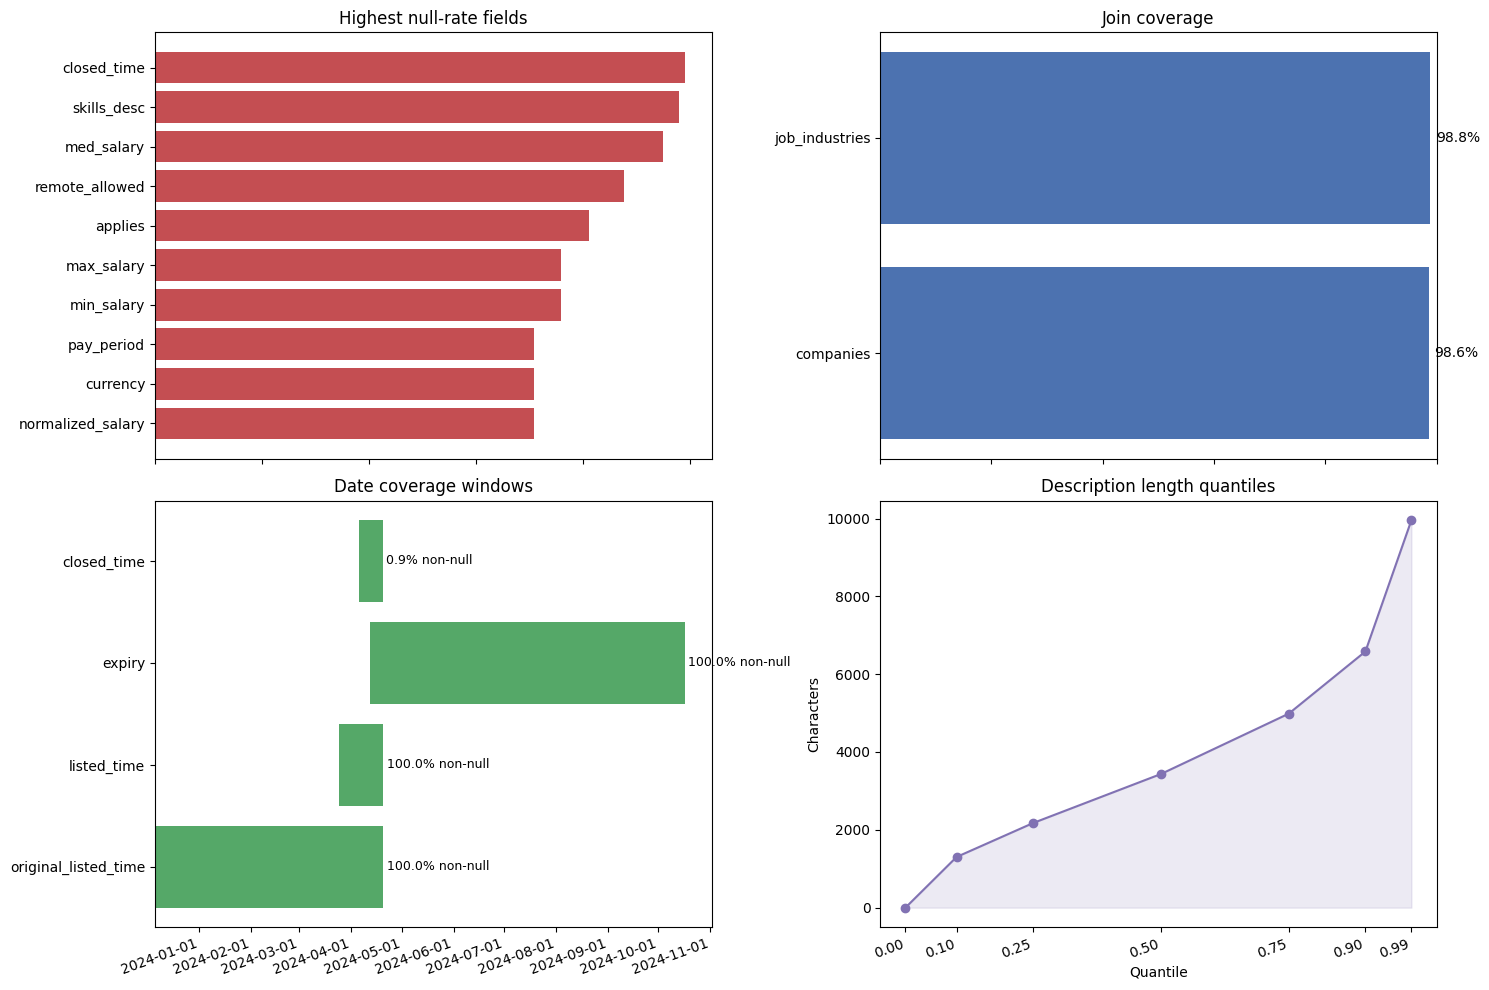

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

audit_dir = Path("../results/audit")
summary = pd.read_csv(audit_dir / "audit_summary.csv")
null_rates = pd.read_csv(audit_dir / "null_rates.csv").sort_values("null_pct", ascending=True).tail(10)
dates = pd.read_csv(audit_dir / "date_coverage.csv")
joins = pd.read_csv(audit_dir / "join_coverage.csv")
text_lengths = pd.read_csv(audit_dir / "text_length_summary.csv").sort_values("quantile")

row_total = float(summary.loc[summary["metric"].eq("rows"), "value"].iloc[0])
joins["match_rate"] = joins["matched_rows"] / joins["total_rows"] * 100

date_plot = dates.copy()
date_plot["min"] = pd.to_datetime(date_plot["min"], errors="coerce")
date_plot["max"] = pd.to_datetime(date_plot["max"], errors="coerce")
date_plot["span_days"] = (date_plot["max"] - date_plot["min"]).dt.total_seconds() / 86400
date_plot["coverage_pct"] = date_plot["non_null"] / row_total * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].barh(null_rates["column"], null_rates["null_pct"], color="#c44e52")
axes[0, 0].set_title("Highest null-rate fields")
axes[0, 0].set_xlabel("Percent null")

axes[0, 1].barh(joins["join"], joins["match_rate"], color="#4c72b0")
axes[0, 1].set_title("Join coverage")
axes[0, 1].set_xlabel("Matched rows (%)")
axes[0, 1].set_xlim(0, 100)
for idx, value in enumerate(joins["match_rate"]):
    axes[0, 1].text(value + 1, idx, f"{value:.1f}%", va="center")

left = mdates.date2num(date_plot["min"])
max_dates = mdates.date2num(date_plot["max"])
axes[1, 0].barh(date_plot["column"], date_plot["span_days"], left=left, color="#55a868")
axes[1, 0].set_title("Date coverage windows")
axes[1, 0].xaxis_date()
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
for idx, (_, row) in enumerate(date_plot.iterrows()):
    axes[1, 0].text(max_dates[idx] + 2, idx, f"{row['coverage_pct']:.1f}% non-null", va="center", fontsize=9)

axes[1, 1].plot(text_lengths["quantile"], text_lengths["description_length"], marker="o", color="#8172b3")
axes[1, 1].fill_between(text_lengths["quantile"], text_lengths["description_length"], alpha=0.15, color="#8172b3")
axes[1, 1].set_title("Description length quantiles")
axes[1, 1].set_xlabel("Quantile")
axes[1, 1].set_ylabel("Characters")
axes[1, 1].set_xticks(text_lengths["quantile"])

fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plot_name = "Step 1 - Report Visual Aids"
plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches="tight")
plt.show()
